In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cd /content/drive/MyDrive/dl_project

In [ ]:
!ls /content/drive/MyDrive/dl_project

 FSDD_dataset   FSDD_multi_dataset  'FSDD_multi_dataset(1500)'	 own_dataset


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/dl_project/FSDD_multi_dataset(1500)"
files = os.listdir(dataset_path)
print("Total files:", len(files))
print(files)

Total files: 1500
['01_jackson_4.wav', '01_jackson_3.wav', '00_jackson_0.wav', '02_jackson_1.wav', '00_jackson_2.wav', '00_jackson_4.wav', '01_jackson_0.wav', '00_jackson_1.wav', '01_jackson_1.wav', '02_jackson_0.wav', '02_jackson_3.wav', '00_jackson_3.wav', '01_jackson_2.wav', '02_jackson_2.wav', '03_jackson_4.wav', '04_jackson_1.wav', '03_jackson_3.wav', '03_jackson_1.wav', '03_jackson_2.wav', '04_jackson_4.wav', '04_jackson_3.wav', '05_jackson_2.wav', '05_jackson_0.wav', '05_jackson_4.wav', '06_jackson_2.wav', '04_jackson_0.wav', '04_jackson_2.wav', '05_jackson_3.wav', '05_jackson_1.wav', '06_jackson_0.wav', '03_jackson_0.wav', '02_jackson_4.wav', '06_jackson_1.wav', '08_jackson_0.wav', '09_jackson_0.wav', '08_jackson_4.wav', '10_jackson_0.wav', '07_jackson_3.wav', '08_jackson_1.wav', '09_jackson_3.wav', '07_jackson_2.wav', '07_jackson_0.wav', '09_jackson_2.wav', '09_jackson_1.wav', '08_jackson_2.wav', '06_jackson_3.wav', '07_jackson_1.wav', '06_jackson_4.wav', '07_jackson_4.wav', '

In [ ]:

import os

dataset_own_path = "/content/drive/MyDrive/dl_project/own_dataset"
files_own = os.listdir(dataset_own_path)
print("Total files:", len(files_own))
print(files_own)

Total files: 1500
['87_chershil_3.wav', '71_chershil_4.wav', '01_chershil_0.wav', '28_elango_3.wav', '72_swarup_1.wav', '27_swarup_1.wav', '80_chershil_2.wav', '87_chershil_1.wav', '88_chershil_3.wav', '56_swarup_2.wav', '82_elango_3.wav', '03_swarup_2.wav', '64_chershil_4.wav', '42_swarup_4.wav', '92_chershil_1.wav', '51_swarup_2.wav', '14_chershil_0.wav', '09_chershil_1.wav', '95_chershil_2.wav', '83_elango_4.wav', '17_swarup_4.wav', '29_elango_4.wav', '20_swarup_1.wav', '65_chershil_0.wav', '70_chershil_0.wav', '85_elango_3.wav', '68_elango_2.wav', '06_chershil_3.wav', '59_elango_0.wav', '97_elango_2.wav', '11_swarup_3.wav', '67_swarup_0.wav', '32_swarup_0.wav', '13_chershil_3.wav', '75_swarup_1.wav', '98_swarup_0.wav', '44_swarup_3.wav', '43_swarup_3.wav', '16_swarup_3.wav', '60_swarup_1.wav', '78_chershil_1.wav', '77_chershil_2.wav', '62_chershil_3.wav', '35_swarup_1.wav', '90_elango_2.wav', '77_chershil_3.wav', '60_swarup_0.wav', '00_chershil_4.wav', '19_elango_1.wav', '35_swarup

In [ ]:
!pip install librosa

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset

class MFCCDataset(Dataset):
    def __init__(self, files, path):
        self.files = files
        self.path = path

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]

        # label (00–99 → int)
        label = int(file.split("_")[0])

        y, sr = librosa.load(os.path.join(self.path, file), sr=8000)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        #  normalize
        mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

        #  pad / truncate
        max_len = 32
        if mfcc.shape[1] < max_len:
            pad = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0),(0,pad)))
        else:
            mfcc = mfcc[:, :max_len]

        mfcc = torch.tensor(mfcc, dtype=torch.float32)

        return mfcc, label

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_files, val_files = train_test_split(files, test_size=0.2, random_state=42)
#for testing own
train_own_files, val_own_files = train_test_split(files_own, test_size=0.2, random_state=42)
train_dataset = MFCCDataset(train_files, dataset_path)
#val_dataset = MFCCDataset(val_files, dataset_path)
val_dataset = MFCCDataset(val_own_files, dataset_own_path)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
print(len(train_dataset),len(val_dataset))

1200 300


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(32 * 10 * 8, 128)
        self.fc2 = nn.Linear(128, 100)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,40,32)

        x = self.pool(F.relu(self.conv1(x)))  # (B,16,20,16)
        x = self.pool(F.relu(self.conv2(x)))  # (B,32,10,8)

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 15

for epoch in range(epochs):
    # TRAIN
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = 100 * correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

Epoch 1/15 | Train Acc: 0.667 | Val Acc: 0.667
Epoch 2/15 | Train Acc: 2.083 | Val Acc: 0.667
Epoch 3/15 | Train Acc: 3.833 | Val Acc: 2.000
Epoch 4/15 | Train Acc: 9.250 | Val Acc: 4.000
Epoch 5/15 | Train Acc: 16.333 | Val Acc: 3.000
Epoch 6/15 | Train Acc: 24.833 | Val Acc: 4.000
Epoch 7/15 | Train Acc: 34.083 | Val Acc: 3.000
Epoch 8/15 | Train Acc: 46.083 | Val Acc: 4.333
Epoch 9/15 | Train Acc: 48.000 | Val Acc: 3.333
Epoch 10/15 | Train Acc: 58.083 | Val Acc: 3.000
Epoch 11/15 | Train Acc: 63.833 | Val Acc: 4.000
Epoch 12/15 | Train Acc: 68.583 | Val Acc: 3.000
Epoch 13/15 | Train Acc: 70.417 | Val Acc: 3.667
Epoch 14/15 | Train Acc: 76.250 | Val Acc: 1.333
Epoch 15/15 | Train Acc: 80.000 | Val Acc: 3.000


In [ ]:
model.eval()

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2560, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=100, bias=True)
)

In [ ]:
import librosa
import numpy as np
import torch

def predict_audio(file_path, model, device):
    # Load audio
    y, sr = librosa.load(file_path, sr=8000)

    # Extract MFCC (same as training)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    # Normalize
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

    # Pad / truncate (same as training)
    max_len = 32
    if mfcc.shape[1] < max_len:
        pad = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad)))
    else:
        mfcc = mfcc[:, :max_len]

    # Convert to tensor
    mfcc = torch.tensor(mfcc, dtype=torch.float32)
    mfcc = mfcc.unsqueeze(0)  # (1, 40, 32)
    mfcc = mfcc.to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(mfcc)
        _, predicted = torch.max(outputs, 1)

    return predicted.item()

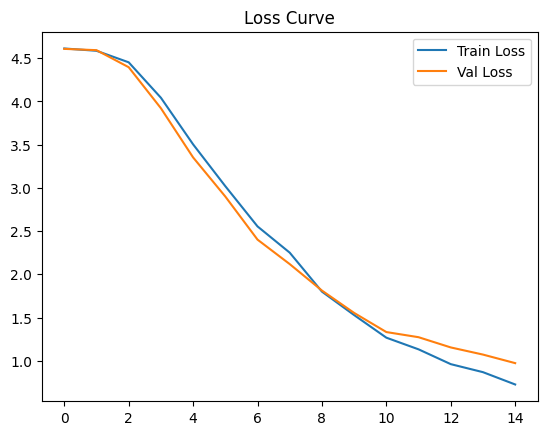

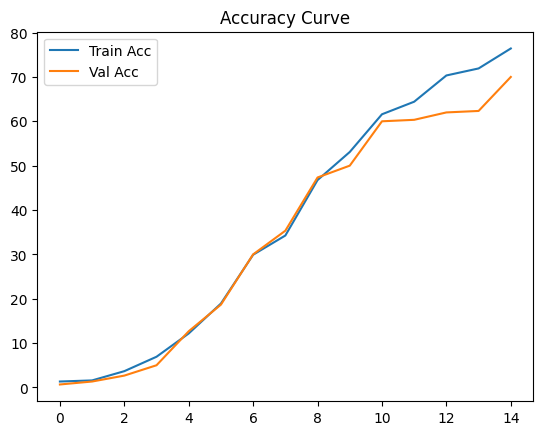

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
model.eval()

NameError: name 'model' is not defined

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=40,   # MFCC features
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 100)  # 100 classes

    def forward(self, x):
        # x: (B, 40, 32)

        x = x.permute(0, 2, 1)  # (B, 32, 40)

        out, _ = self.lstm(x)

        # take last time step
        out = out[:, -1, :]  # (B, 128)

        out = self.dropout(torch.relu(self.fc1(out)))
        out = self.fc2(out)

        return out

In [ ]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = CNNModel().to(device)
model = LSTMModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accs = []
val_accs = []

epochs = 15

for epoch in range(epochs):
    # TRAIN
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = 100 * correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

Epoch 1/15 | Train Acc: 0.750 | Val Acc: 0.667
Epoch 2/15 | Train Acc: 1.083 | Val Acc: 0.667
Epoch 3/15 | Train Acc: 1.000 | Val Acc: 0.667
Epoch 4/15 | Train Acc: 1.000 | Val Acc: 0.667
Epoch 5/15 | Train Acc: 0.750 | Val Acc: 0.667
Epoch 6/15 | Train Acc: 0.750 | Val Acc: 0.333
Epoch 7/15 | Train Acc: 1.167 | Val Acc: 0.333
Epoch 8/15 | Train Acc: 0.917 | Val Acc: 0.000
Epoch 9/15 | Train Acc: 1.750 | Val Acc: 0.667
Epoch 10/15 | Train Acc: 0.833 | Val Acc: 0.667
Epoch 11/15 | Train Acc: 1.333 | Val Acc: 0.667
Epoch 12/15 | Train Acc: 2.083 | Val Acc: 0.667
Epoch 13/15 | Train Acc: 2.583 | Val Acc: 1.333
Epoch 14/15 | Train Acc: 2.250 | Val Acc: 0.333
Epoch 15/15 | Train Acc: 2.167 | Val Acc: 1.667


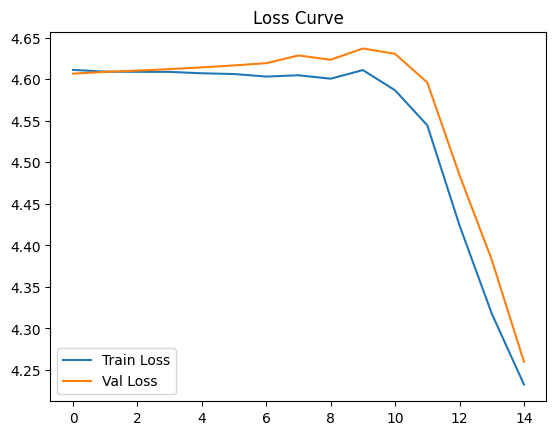

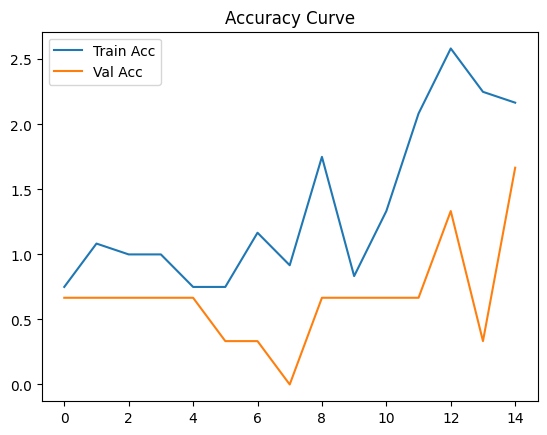

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()